# Syllabus:

1. [Introduction to Generative Computer Vision](#introduction-to-generative-computer-vision)
2. [Core Architectures](#core-architectures)
3. [Core Generative Tasks & Applications](#core-generative-tasks--applications)
    
    1. [Toolset](#toolset)
    2. [Core Image Generation](#core-image-generation)
    3. [Image Editing & Modification](#image-editing--modification)
    4. [Multi-Model Interaction](#multi-modal-interaction)


In [18]:
from IPython.display import Video, Image

# Introduction to Generative Computer Vision

Previously discussed tasks were mostly focused on *classifying* or *regressing* **labels** - processing of raw pixels in order to learn data patterns (as features) based on (mostly) supervised dataset. Such as regressing box position and labels (for object detection tasks), regressing keypoints position, classifying segments, etc. 

Models that learn to distiguish different classes based on boundaries are called `discriminative`.

However, AI and CV, in particular, have another branch called `generative AI` that focuses on producing new samples based on learned distributions.

Thus, generative CV maps an input (noisy or partially) into a new or completed image (filling missing regions, upsampling, sampling new imaginary, etc.).

![Example of differences based on distribution](https://media.licdn.com/dms/image/v2/D4E22AQE8oMauLRwPmw/feedshare-shrink_800/feedshare-shrink_800/0/1692976294975?e=2147483647&v=beta&t=LHzHDnpuHEAothmQbEXRSfwrUv2qqV_Vl9APIgMVKkU)

## Where Generative AI in Vision can be used?

Let's review high-level application of the Generative AI in Vision:

- Creative Content Creation:

![GPT-4o infographic creation](https://images.ctfassets.net/kftzwdyauwt9/CeeiDaB6U4mQmawnCIpaB/5a4fd1fc66da9ba560af1dd1dc707949/newtons1.png?w=828&q=90&fm=webp)

![Gemini creation](https://lh3.googleusercontent.com/Qfy67xGYqjHeqiXGf7zSdNOzlaBCPuTMvmjkSPo2Sqq3YKm5VU0mF1OD1gzprv2L6eb6V20YIwO7ehcXxBTcfdUV3eHs4gfdSTdc6Q=e365-pa-nu-w1906)


![Italian brainrot surrealism](https://static.dagospia.com/img/patch/05-2025/italian-brain-rot-brainrot-2126483_600_q50.webp)



In [19]:
"""Prompt: A woman, classical violinist with intense focus plays a complex, rapid passage from a Vivaldi concerto in an ornate,
sunlit baroque hall during a rehearsal. Their bow dances across the strings with virtuosic speed and precision.

Audio: Bright, virtuosic violin playing, resonant acoustics of the hall, distant footsteps of crew,
conductor's occasional soft count-in (muffled), rustling sheet music."""

# Veo 3 - recent (06.06.2025) model from Google that generates short up to 8 seconds videos with audio

Video(url='https://deepmind.google/api/blob/website/media/veo__veo-3__us_wm_a-african-american-classical-violinist-with-intense-focus-plays-_1.mp4')

Can be used as tools for art and content assets for artists, designers and people without any experience in graphic design.


- Data Augmentation:

![Image Synthesis](https://cdn.prod.website-files.com/62cd5ce03261cb3e98188470/682b41a73d16568731b749d3_AD_4nXdguB7wvp2SrMYgedany2PqGUOQQsOzNvrxMK-HbIZ9IpNgIsYCYBoJHcoOD4CIKB4GNXys28PpqF5mUQXDfZ2w5-gchOvVI5Z5YFWTk-lk1FqyNoa1xFVYEOJ3l0EM_qIB64_IhQ.png)



- Image Restoration & Enhancement:

![Grid with examples](https://ar5iv.labs.arxiv.org/html/2308.09388/assets/fig/restoration_tasks.png)

<br>

![Example of Photoshop generative inpainting capabilities](https://images.squarespace-cdn.com/content/v1/631758e1148c0548900ead1a/80d7f63c-1b81-4e38-8cd7-743b207cae64/photoshop.gif)

- Domain Translation & Style Transfer:


![image-to-image translation example](https://media.springernature.com/full/springer-static/image/art%3A10.1038%2Fs41598-024-80508-w/MediaObjects/41598_2024_80508_Fig1_HTML.jpg)


# Core Architectures

## Variational Autoencoder (VAE)

- Has similar architecture to Autoencoder
- Encoded information results in distribution over latent space (unlike a point in latent space as in AE)
- Samples learned distribution to generate new, realistic data



![VAE architecture](https://lilianweng.github.io/posts/2018-08-12-vae/autoencoder-architecture.png)


### Strengths

- Structured latent space - useful for controlled generation and interpolation.
- Stable training - straightforward loss function.
- Reconstruction-focused - good at compressing input data.


### Weaknesses

- Blurry outputs due to Gaussian assumptions and pixel-wise loss.
- Lower visual fidelity.
- Struggles to model fine-grained visual details.



### Image morphing

`Image morphing` is the smooth transformation of one image into another, blending their features in a gradual and natural-looking way.

VAEs possess specific characteristics that make image morphing straightforward and effective:

- Continuous and Smooth Latent Space (which is usually regularized) - meaning you can interpolate valid vectors between specific vectors
- Semantic Consistency - the decoder interprets intermediate latent points as semantically meaningful, rather than producing noisy or nonsensical outputs


![Example of such morphing](https://miro.medium.com/v2/resize:fit:1280/0*dwtvGrRWRAUJuZm4.gif)

### Basic PyTorch implementation

In [ ]:
import torch
import torch.nn as nn


class Encoder(nn.Module):
    def __init__(self, hidden_channels: int, latent_dim: int) -> None:
        """
        Simple encoder module

        It predicts the `mean` and `log(variance)` parameters.

        The choice to use the `log(variance)` is for stability reasons:
        https://stats.stackexchange.com/a/353222/284141
        """
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=1,
                               out_channels=hidden_channels,
                               kernel_size=4,
                               stride=2,
                               padding=1) # out: hidden_channels x 14 x 14

        self.conv2 = nn.Conv2d(in_channels=hidden_channels,
                               out_channels=hidden_channels*2,
                               kernel_size=4,
                               stride=2,
                               padding=1) # out: (hidden_channels x 2) x 7 x 7

        self.fc_mu = nn.Linear(in_features=hidden_channels*2*7*7,
                               out_features=latent_dim)
        self.fc_logvar = nn.Linear(in_features=hidden_channels*2*7*7,
                                   out_features=latent_dim)

        self.activation = nn.ReLU()

    def forward(self, x: torch.Tensor) -> (torch.Tensor, torch.Tensor):
        """
        :param x: batch of images with shape [batch, channels, w, h]
        :returns: the predicted mean and log(variance)
        """
        x = self.activation(self.conv1(x))
        x = self.activation(self.conv2(x))

        x = x.view(x.shape[0], -1)

        x_mu = self.fc_mu(x)
        x_logvar = self.fc_logvar(x)

        return x_mu, x_logvar

class Decoder(nn.Module):
    def __init__(self, hidden_channels: int, latent_dim: int) -> None:
        """
        Simple decoder module
        """
        super().__init__()
        self.hidden_channels = hidden_channels

        self.fc = nn.Linear(in_features=latent_dim,
                            out_features=hidden_channels*2*7*7)

        self.conv2 = nn.ConvTranspose2d(in_channels=hidden_channels*2,
                                        out_channels=hidden_channels,
                                        kernel_size=4,
                                        stride=2,
                                        padding=1)
        self.conv1 = nn.ConvTranspose2d(in_channels=hidden_channels,
                                        out_channels=1,
                                        kernel_size=4,
                                        stride=2,
                                        padding=1)

        self.activation = nn.ReLU()


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        :param x: a sample from the distribution governed by the mean and log(var)
        :returns: a reconstructed image with size [batch, 1, w, h]
        """
        x = self.fc(x)
        x = x.view(x.size(0), self.hidden_channels*2, 7, 7)
        x = self.activation(self.conv2(x))
        x = torch.sigmoid(self.conv1(x)) # last layer before output is sigmoid, since we are using BCE as reconstruction loss
        return x


In [ ]:
class VariationalAutoencoder(nn.Module):
    def __init__(self, hidden_channels: int, latent_dim: int):
        super().__init__()
        self.encoder = Encoder(hidden_channels=hidden_channels,
                               latent_dim=latent_dim)
        self.decoder = Decoder(hidden_channels=hidden_channels,
                               latent_dim=latent_dim)

    def forward(self, x):
        latent_mu, latent_logvar = self.encoder(x)
        latent = self.latent_sample(latent_mu, latent_logvar)
        x_recon = self.decoder(latent)
        return x_recon, latent_mu, latent_logvar

    def latent_sample(self, mu, logvar):

        if self.training:
            # the reparameterization trick
            std = (logvar * 0.5).exp()
            return torch.distributions.Normal(loc=mu, scale=std).rsample()
            # std = logvar.mul(0.5).exp_()
            # eps = torch.empty_like(std).normal_()
            # return eps.mul(std).add_(mu)
        else:
            return mu


In [ ]:
latent_dims = 2
num_epochs = 40
batch_size = 128
capacity = 64
learning_rate = 1e-3
variational_beta = 1
use_gpu = True

device = torch.device("cuda:0" if use_gpu and torch.cuda.is_available() else "cpu")


vae = VariationalAutoencoder(hidden_channels=capacity, latent_dim=latent_dims)
vae = vae.to(device)

num_params = sum(p.numel() for p in vae.parameters() if p.requires_grad)
print('Number of parameters: %d' % num_params)

More detailed guide to VAE and its training is presented [in this notebook](https://colab.research.google.com/github/lucmos/DLAI-s2-2020-tutorials/blob/master/08/8_Variational_Autoencoders_(VAEs).ipynb).

### Controlled generation using latent space

Core ideas for controlled generation are:

- In VAEs, inputs are encoded into a structured, continuous latent space.
- Each point in this space corresponds to a specific variation of the data.
- By exploring or modifying this space, we can generate controlled and meaningful outputs.

Thus, it's possible to perform following operations on the image:

![Example of influencing latent space](https://houxianxu.github.io/assets/projects/dfcvae/combined.gif)


By determining what representation does some specific attribute have - you can influence (add or substract vector) the generation.

Keras implementation - https://github.com/farhad-dalirani/Controllable-Face-Generation-VAE/blob/main/variational_autoencoder.py

Full project - https://github.com/farhad-dalirani/Controllable-Face-Generation-VAE/tree/main




### Conditional VAE

Another architecture based on VAE was developed for conditional generation - called `Conditional VAE`.

Depending on the training process, it allows to pass conditions for controlled generation.


![Conditional VAE architecture](https://media.datacamp.com/cms/google/ad_4nxc9e-fxwecmh3e_zz4vgeiokxpdjuhexeca3dzysa2cf-choq0uchs39pdlqai6pd7lsdau3ptrjs_nofsuem1whkrxfogviyvlmdsjw05xzfpsljmzdyddua_t9hdnrrhup0mqpw0fualz4sdfachhgbak.png)

## GANs




GANs are a class of generative models that `learn to produce realistic data` (e.g., images) by training two neural networks in opposition:

- **Generator (G)**: Creates fake data from random noise.

- **Discriminator (D)**: Distinguishes real data from fake.


![GAN architecture](https://www.researchgate.net/publication/356809414/figure/fig1/AS:1098577317244930@1638932651307/Example-of-GAN-Architecture.ppm)

Up to development of diffusion models, GAN have been the SOTA of all generative tasks.

Here's a short list of basic tasks and corresponding models/architectures that leveraged GANs:

1. **High‑Resolution Image Synthesis**

   * *Task:* Generate photorealistic images from random noise.
   * *Examples:* StyleGAN / StyleGAN2 (progressive style control), BigGAN (class‑conditional large‑scale synthesis).

2. **Image Super‑Resolution**

   * *Task:* Upscale low‑resolution images while restoring fine details.
   * *Example:* SRGAN (Super‑Resolution GAN) uses a perceptual loss to produce sharper outputs.

3. **Image‑to‑Image Translation**

   * *Task:* Translate images from one domain to another (e.g., sketches-photos, summer-winter).
   * *Examples:*

     * **pix2pix** (paired training)
     * **CycleGAN** (unpaired, cycle‑consistency losses)

4. **Image Inpainting**

   * *Task:* Fill in missing or occluded regions in images.
   * *Example:* Context Encoder (encoder‑decoder GAN with reconstruction + adversarial losses).

5. **Style Transfer**

   * *Task:* Re-render photos in the style of famous artists or other target domains.
   * *Examples:*

     * **CycleGAN** (unpaired style transfer)
     * **StyleGAN** variants for artistic style synthesis.

6. **Data Augmentation**

   * *Task:* Synthesize additional training samples to balance or enrich datasets.
   * *Example:* DCGAN‑based pipelines for augmenting small medical or industrial image sets.

7. **Text‑to‑Image Generation**

   * *Task:* Turn textual descriptions into corresponding images.
   * *Examples:* StackGAN (two‑stage), AttnGAN (attention‑driven), MirrorGAN.

8. **Domain Adaptation**

   * *Task:* Adapt a model trained on one domain (e.g., synthetic) to perform well on another (e.g., real).
   * *Example:* CyCADA (Cycle‑Consistent Adversarial Domain Adaptation).

9. **Anomaly Detection**

   * *Task:* Identify outliers by measuring how well GAN can reconstruct or model “normal” data.
   * *Example:* AnoGAN (uses reconstruction error in latent space as anomaly score).

10. **Face Editing & Attribute Manipulation**

    * *Task:* Change specific facial attributes (age, hair color, expression) while preserving identity.
    * *Examples:* StarGAN (multi‑domain), GANimation (expression transfer).

11. **Video Frame Generation**

    * *Task:* Generate coherent video sequences or interpolate between frames.
    * *Example:* MoCoGAN (decomposes motion and content in latent space).

12. **3D Object & Scene Generation**

    * *Task:* Synthesize 3D shapes or voxel grids from noise or 2D priors.
    * *Example:* 3D‑GAN (voxel‑based), PrGAN (point cloud generation).


### Strengths

- Sharp and realistic images - often best for fine texture and detail.

- Fast sampling - one-pass generation after training.

- Flexible for many vision tasks (e.g., translation, editing, super-resolution).

### Weaknesses

- Unstable training - prone to mode collapse and sensitivity to hyperparameters (due to 2 networks).

- No explicit likelihood - hard to evaluate model performance.

- Difficult to interpret latent space.

- Mode Collapse: Situation when generator produces a limited variety of outputs, often very similar to each other, instead of a diverse set that reflects the real data distribution. 

In [1]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

import urllib.request as url_req

(-0.5, 1023.5, 1023.5, -0.5)

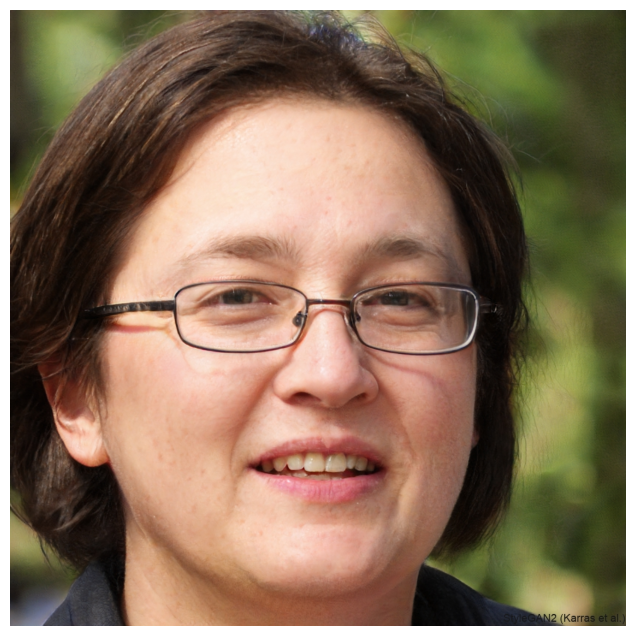

In [3]:
image_url = 'https://thispersondoesnotexist.com/'
hdr = {
    'User-Agent': 'Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.11 (KHTML, like Gecko) Chrome/23.0.1271.64 Safari/537.11',
    'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8',
    }

req = url_req.urlopen(url_req.Request(image_url, headers=hdr))
nparr = np.asarray(bytearray(req.read()), dtype=np.uint8)
image = cv2.imdecode(nparr, cv2.IMREAD_COLOR)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.imshow(image)
plt.axis('off')

## Diffusion models

- Probabilistic generative models that learn to generate data by `reversing a gradual noising process`.

- Trained to `denoise data step by step` from pure noise to realistic samples.

As backbone, diffusion model can use either `U-Net` or `Diffusion Transformer`.


Example of process:

![Process example](https://learnopencv.com/wp-content/uploads/2023/01/diffusion-models-unconditional_image_generation-1.gif)

<h3>Check:</h3>

- [simple visual article from Washington Post](https://www.washingtonpost.com/technology/interactive/2022/ai-image-generator/) as a overview of how controlled diffusion models work

- [more complex visual article](https://erdem.pl/2023/11/step-by-step-visual-introduction-to-diffusion-models) that shows how U-Net architecture works for diffusers

- [Hugging Face class](https://github.com/huggingface/diffusion-models-class) on diffusion models - their inference and finetuning

- [very intense CVPR tutorial](https://cvpr2022-tutorial-diffusion-models.github.io/) on theory of diffusion models


### Latent Diffusion model architecture:

![Diffusion model architecture](https://lilianweng.github.io/posts/2021-07-11-diffusion-models/latent-diffusion-arch.png)

It uses elements of following architecures:
- CLIP for building latent space for text and image representation
- VAE as compressing object into latent space and decompressing it
- U-Net - by training to apply noise and denoise

### Strengths

- High-quality generation - rivals or exceeds GANs on many benchmarks.

- Efficient training via latent space (vs. pixel space).

- Flexible conditioning - supports text, masks, sketches (e.g., Stable Diffusion).

- Stable training - no adversarial component.


### Weaknesses

- Slow inference - requires many steps (though mitigated by DDIM, distillation).

- Complex architecture - harder to implement or fine-tune.

- Latent bottleneck may limit detail resolution in some use cases.


# Core Generative Tasks & Applications

## Toolset

[Hugging Face `diffusers`](https://huggingface.co/docs/diffusers/main/en/index) is the go-to library for state-of-the-art pretrained diffusion models for generating images, audio, and even 3D structures of molecules.

In [ ]:
!pip install diffusers

- [ComfyUI - UI experimentation](https://github.com/comfyanonymous/ComfyUI)
- [Stable Diffusion WebUI - UI experimentation](https://github.com/AUTOMATIC1111/stable-diffusion-webui)
- [CivitAI - hub of fined-tuned model checkpoints](https://civitai.com/)
- [HF model index](https://huggingface.co/models)
- [HF Spaces](https://huggingface.co/spaces)
- [OneTrainer - training](https://github.com/Nerogar/OneTrainer)

## Core Image Generation

### Unconditional Image Generation

**Core ideas**:

- Focuses on learning distributions and patterns of trained data (usually specific classes or entities, so the model sees large variations of one entity).

- Generates images without any conditional signal - only pure noise/vector space.


**Models**:
- VAEs
- GANs
- DDPM (diffusion-based)

Use [Hugging Face Model Index](https://huggingface.co/models?pipeline_tag=unconditional-image-generation&sort=trending) to find more examples.



/home/work/Work/custom/.venv/lib/python3.10/site-packages/transformers/utils/generic.py:441: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  _torch_pytree._register_pytree_node(
/home/work/Work/custom/.venv/lib/python3.10/site-packages/transformers/utils/generic.py:309: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  _torch_pytree._register_pytree_node(
/home/work/Work/custom/.venv/lib/python3.10/site-packages/transformers/utils/generic.py:309: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  _torch_pytree._register_pytree_node(


model_index.json:   0%|          | 0.00/180 [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

scheduler_config.json:   0%|          | 0.00/256 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/699 [00:00<?, ?B/s]

diffusion_pytorch_model.bin:   0%|          | 0.00/143M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch /home/work/.cache/huggingface/hub/models--google--ddpm-cifar10-32/snapshots/267b167dc01f0e4e61923ea244e8b988f84deb80: Error no file named diffusion_pytorch_model.safetensors found in directory /home/work/.cache/huggingface/hub/models--google--ddpm-cifar10-32/snapshots/267b167dc01f0e4e61923ea244e8b988f84deb80.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


  0%|          | 0/1000 [00:00<?, ?it/s]

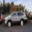

In [13]:
# !pip install diffusers
from diffusers import DDPMPipeline, DDIMPipeline, PNDMPipeline

model_id = "google/ddpm-cifar10-32"

# load model and scheduler
ddpm = DDPMPipeline.from_pretrained(model_id)  # you can replace DDPMPipeline with DDIMPipeline or PNDMPipeline for faster inference

# run pipeline in inference (sample random noise and denoise)
image = ddpm().images[0]

# save image
image


In [14]:
image.save("ddpm_cifar10_sample.png")

Also, you can use [OpenMMLab Generation library](https://github.com/open-mmlab/mmgeneration).

### Conditional (Controlled) Image Generation

**Core ideas:**

- Generate images `conditioned on extra information` such as class labels, segmentation maps, or text. It requires the model to understand objects, attributes, artistic styles, and their complex relationships.

- Nowadays (2025), the most frequent use-case is Text-to-Image generation (`prompts`).


**Models**:
- BigGAN
- Stable Diffusion (SD1.5, SDXL, etc.)
- FLUX

*Proprietary models*:
- DALL-E
- Midjourney
- Imagen

Use [Hugging Face Model Index](https://huggingface.co/models?pipeline_tag=text-to-image&sort=downloads) to find more examples.

In [20]:
from diffusers import StableDiffusionPipeline
import torch

model_id = "sd-legacy/stable-diffusion-v1-5"
pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16)
pipe = pipe.to("cuda")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

In [ ]:
prompt = "Nature landscape with mountains and a river, in the style of a watercolor painting"
generator = torch.manual_seed(42)
image = pipe(prompt, generator=generator).images[0]

image

Try [Hugging Face Spaces](https://huggingface.co/spaces/black-forest-labs/FLUX.1-dev) to inference model on HF servers. 

### Image-to-Image Translation

**Core ideas:**

- Convert an input image from one domain to another (e.g., sketches→photos, summer→winter scenes) while preserving structure.
- Can be used for controling Text-to-Image generation with inital state as additionally supplied image.


*Domains*:
- Paired translation
- Unpaired translation

**Models**:
- Pix2Pix
- MUNIT
- CycleGAN
- Stable Diffusion Img2Img

<h4>Example of Pix2Pix pipeline</h4>

![Pix2Pix samples](https://github.com/phillipi/pix2pix/raw/master/imgs/examples.jpg)

Use [Hugging Face Model Index](https://huggingface.co/models?pipeline_tag=image-to-image&sort=downloads) to find more examples.


In [ ]:
from PIL import Image
import torch
from diffusers import StableDiffusionImg2ImgPipeline

# load pipeline
pipe = StableDiffusionImg2ImgPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5", torch_dtype=torch.float16
).to("cuda")

In [ ]:
init_image = Image.open("supplementary_data/camels1.jpg").convert("RGB").resize((512,512))
# generate stylized output
images = pipe(
    prompt="Drawing of a camel in the desert, in the style of Van Gogh",
    image=init_image,
    strength=0.7,
    guidance_scale=7.5,
    num_inference_steps=50
).images

images[0]

## Image Editing & Modification

### Inpainting & Outpainting

*Domains* - work on existing image:

- `Inpainting`: Filling in a masked or missing part of an image with contextually plausible content.

- `Outpainting`: Extending the canvas of an image, generating new content beyond its original borders.

*Use cases*: Photo restoration, object removal, creative extension, panorama generation.

**Models**:
- Partial Convolution
- Instruct-Pix2Pix
- Stable Diffusion (SD1.5, SDXL, etc.)
- FLUX

Use [Hugging Face Model Index](https://huggingface.co/models?pipeline_tag=image-to-image&sort=downloads) to find more examples.

[Inpainting example from HF Space](https://huggingface.co/spaces/stepfun-ai/Step1X-Edit).

In [ ]:
from diffusers import StableDiffusionInpaintPipeline
import torch
from PIL import Image

pipe = StableDiffusionInpaintPipeline.from_pretrained(
    "stabilityai/stable-diffusion-2-inpainting", torch_dtype=torch.float16
).to("cuda")

init_img = Image.open("photo.png").convert("RGB").resize((512,512))
mask_img = Image.open("mask.png").convert("L").resize((512,512))

with torch.autocast("cuda"):
    result = pipe(
        prompt="PROMPT",
        image=init_img,
        mask_image=mask_img,
        guidance_scale=7.5,
        num_inference_steps=50
    ).images[0]



[Outpainting example from HF Space](https://huggingface.co/spaces/multimodalart/flux-fill-outpaint).

In [ ]:
from diffusers import StableDiffusionXLPipeline
import torch
from PIL import Image

pipe = StableDiffusionXLPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-outpaint", torch_dtype=torch.float16
).to("cuda")

# `canvas` is a PIL.Image larger than `init_img`, with `init_img` pasted centrally;
# the rest is filled with white or a neutral color
canvas = Image.new("RGB", (768, 512), "white")
init = Image.open("center_image.png").resize((512,512))
canvas.paste(init, (128, 0))

with torch.autocast("cuda"):
    outpainted = pipe(
        prompt="PROMPT",
        image=canvas,
        mask_image=None,            # pipeline infers masked border
        guidance_scale=7.0,
        num_inference_steps=60
    ).images[0]


### Style Transfer

**Core idea**:
- Applying the visual style (textures, colors, brushstrokes) of one image to the content (structure, objects) of another.
- Similar task to Image-to-Image translation.


*Use cases*: Artistic filters, creative tools, design prototyping


**Models**:
- Fast Style Transfer
- StyleCLIP (text-guided)
- Stable Diffusion (SD1.5, SDXL, etc.)
- FLUX


<h4>Examples using Flux (diffusion model), initial image and guided prompt with image</h4>

![Example 1](https://preview.redd.it/flux-guided-sdxl-style-transfer-trick-v0-4jxgeik7i9hd1.jpg?width=1080&crop=smart&auto=webp&s=d0e3d5978382a70b6a198afc18bf8a1a3a31694d)

![Example 2](https://preview.redd.it/flux-guided-sdxl-style-transfer-trick-v0-f2dbzik7i9hd1.jpg?width=1080&crop=smart&auto=webp&s=de4d6c94054cc2b421a485d2db208b8a9c5982db)

### Super-resolution & Restoration

**Core ideas:**

- **Super-Resolution (SR)**: Enhancing image resolution from low to high while preserving details.

- **Restoration**: Removing artifacts such as noise, blur, or compression errors to recover clean images (again, similar to inpainting).


*Use cases*: Medical imaging, surveillance, film remastering, photo enhancement.


**Models**:
- ESRGAN
- SwinIR
- IR-SDE




[HF Space example](https://huggingface.co/spaces?category=image-upscaling)

In [ ]:
# pip install git+https://github.com/doevent/Real-ESRGAN.git

import torch
from PIL import Image
from RealESRGAN import RealESRGAN
import gradio as gr

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model2 = RealESRGAN(device, scale=2)
model2.load_weights('weights/RealESRGAN_x2.pth', download=True)


In [ ]:
image = Image.open("input_image.jpg").convert("RGB")

result = model2.predict(image.convert('RGB'))
result.save("output_image.jpg")

## Multi-Modal Interaction

### Image Captioning

**Core ideas**:
- Image captioning is the task of generating natural language descriptions for images.
- Combines computer vision (understanding image content) and natural language generation (producing fluent text).

*Use cases*: Accessibility (alt text), content indexing, visual question answering, AI-generated content.


*Models*:
- CLIP (OpenAI)
- BLIP
- Generative Image-to-Text (Microsoft)
- SigLIP


#### Contrastive Language-Image Pre-Training (CLIP)

Contrastive Language-Image Pre-Training (CLIP) model that forms a joint embedding space for images and text, such that image and captions corresponding to similar concepts have similar embeddings.

**Architecture**:

- CLIP is comprised of `two encoder modules` that are used to encode `textual` and `image` data.
- Tuning is achieved via:
    
    - passing a group of images and textual captions through their respective encoders

    - maximizing the cosine similarity between image and text embeddings of the true image-caption pairs

    - minimizing the cosine similarity between all other image-caption pairs



![CLIP overview](https://images.squarespace-cdn.com/content/v1/627bac599de82a61e1c62c2d/0da58b9a-b73e-46e8-9e41-914b43e3f91b/CLIP1.png?format=2500w)



#### Zero-shot image classification

Zero-shot image classification is the task of `classifying images into categories` that the model **has never seen during training**, by leveraging semantic knowledge (e.g., text, attributes, or language descriptions) about the classes.


In [ ]:
# pass image classes to the model and it will classify most probable pair

from transformers import CLIPProcessor, CLIPModel

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

In [ ]:
init_image = Image.open("supplementary_data/camels1.jpg").convert("RGB").resize((512,512))

inputs = processor(text=["cat", "dog", "camel", "dolphin"], images=image, return_tensors="pt", padding=True)

outputs = model(**inputs)
logits_per_image = outputs.logits_per_image # this is the image-text similarity score
probs = logits_per_image.softmax(dim=1) # we can take the softmax to get the label probabilities
probs

#### Image-to-Text / Captioning

[HF Space example](https://huggingface.co/spaces/pharmapsychotic/CLIP-Interrogator)

In [ ]:
import torch
from PIL import Image
from transformers import BlipProcessor, BlipForConditionalGeneration

processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base", torch_dtype=torch.float16).to("cuda")

In [ ]:
init_image = Image.open("supplementary_data/camels1.jpg").convert("RGB").resize((512,512))

In [ ]:
# conditional image captioning
text = "a photography of"
inputs = processor(init_image, text, return_tensors="pt").to("cuda", torch.float16)

out = model.generate(**inputs)
print(processor.decode(out[0], skip_special_tokens=True))


In [ ]:
# unconditional image captioning
inputs = processor(init_image, return_tensors="pt").to("cuda", torch.float16)

out = model.generate(**inputs)
print(processor.decode(out[0], skip_special_tokens=True))


### Visual QA

Visual Question Answering (VQA) is a multimodal AI task where a system is given:

- An image

- A natural language question

and must `generate a natural language answer`.


**Models**:
- BLIP-2
- LLaVA
- GPT-4v, Llama-3.2 vision, etc. (most multi-modal VLMs)
- Florence-2


[HF Spaces](https://huggingface.co/spaces?category=visual-qa&sort=likes)

### Florence-2

Florence-2 is Microsoft’s next-`generation vision foundation model` (released in 2024), designed for general-purpose computer vision tasks across both images and videos.

**Architecture Overview**:
- Based on Vision Transformers (ViT)

- Uses a task-aware encoder and modular decoders for different tasks

- Supports prompt tuning for zero-shot and few-shot vision tasks


**Use Cases**:
- Image tagging and retrieval

- Grounding and object detection

- Visual question answering

- Video understanding

- Multimodal search


**Architecture:**

![Florence-2 architecture overview](https://images.prismic.io/encord/9bb8ae77-7b87-4196-ae81-4cf9a6da8a83_image1.png?auto=compress,format)



**Check:** [HF Space with example](https://huggingface.co/spaces/gokaygokay/Florence-2)

# Engineering

Notes on:
- practicality of hosting or using services
- practicality of tuning and basic recipes?


## Fine-tuning

Even though generative vision models are trained on large datasets and are quite capable, the need of personalization or improvement of pre-trained model can still occure.

Fine-tuning adapts these general models to specialized tasks or data, improving output quality, control, and relevance.

There are several approaches to fine-tuning generative model:

- full fine-tuning;
- textual inversion;
- DreamBooth;
- low-rank adaptation (LoRA).

### Full fine-tuning

**Full fine-tuning** means updating **all model parameters** (weights) of a pre-trained generative model (e.g., Stable Diffusion, BLIP, GAN) using new data.


[Guide of the training process](https://huggingface.co/docs/diffusers/tutorials/basic_training).

In [ ]:
# Example: fine-tuning a diffusion model using Hugging Face
from diffusers import DDPMScheduler, UNet2DConditionModel
from accelerate import Accelerator

model = UNet2DConditionModel.from_pretrained("stabilityai/stable-diffusion-v1-5")
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)

# Train on custom image/text pairs
for batch in dataloader:
    outputs = model(batch["images"], batch["text_embeddings"])
    loss = loss_fn(outputs, batch["target"])
    loss.backward()
    optimizer.step()


#### Pros/cons

**Pros**:
- Highest possible task performance
- Adapts entire model to your data
- Can change style, structure, and behavior deeply
- Enables training from scratch on top of a strong foundation

**Cons**:
- Very compute-intensive (requires GPUs, longer training)
- Large storage: full model checkpoints (~GBs)
- Risk of overfitting or catastrophic forgetting



### Textual inversion

**Textual Inversion** is a lightweight fine-tuning method that teaches a generative model (e.g., Stable Diffusion) a new concept (object, person, style) by learning a **new text embedding** — a custom token like "`<sk_cat>`". 

It learns a new "word" in the model's vocabulary (a special text embedding) that represents your concept. When you use this new trigger word (e.g., sk_cat), the model is guided toward generating specific cat.


Example:
![Example of textual inversion process](https://textual-inversion.github.io/static/images/editing/teaser.JPG)


**How does it work?**

Schema:
![Schema of the process](https://textual-inversion.github.io/static/images/training/training.JPG)


In the text-encoding stage of most text-to-image models, the **first stage involves converting the prompt into a numerical representation**. This is typically done by converting the words into tokens, each equivalent to an entry in the model's dictionary. 

These entries are then converted into an "embedding" - a continuous vector representation for the specific token. These embeddings are usually learned as part of the training process. 

During textual inversion, algorithm finds new embeddings that represent specific, user-provided visual concepts. 

These embeddings are then **linked to new pseudo-words**, which can be incorporated into new sentences like any other word.



[Guide to training process](https://huggingface.co/docs/diffusers/training/text_inversion) (contains script with recipe).


Loading new encoder and inferencing it:

In [ ]:
from diffusers import StableDiffusionPipeline
import torch

pipeline = StableDiffusionPipeline.from_pretrained("stable-diffusion-v1-5/stable-diffusion-v1-5", torch_dtype=torch.float16).to("cuda")
pipeline.load_textual_inversion("sd-concepts-library/sk_cat")
image = pipeline("A <sk_cat> train", num_inference_steps=50).images[0]
image.save("sk_cat-train.png")


#### Pros/Cons

**Pros:**
- Very lightweight (just a tiny embedding file, ~100KB)
- Fast to train (minutes due to low requirements for needed images)
- Easy to share or combine with other embeddings
- Leaves base model untouched (safe deployment)

**Cons:**
- Limited to 1 concept per token
- Can't alter model behavior deeply (e.g., structure or style rules)
- Output depends heavily on prompt wording
- Not ideal for complex or abstract concepts



### DreamBooth

**DreamBooth** is a fine-tuning method that teaches a generative model (like Stable Diffusion) to generate a specific subject (e.g., a person, pet, object) in various contexts, using just a few images. 

It fine-tunes a *small part of the actual model* (**the cross-attention layers**) to deeply associate a unique identifier (e.g., sks dog) with the subject. It learns the concept much more robustly than Textual Inversion.


Comparison of Textual inversion (1st row) and DreamBooth (2d row) inference:

![Inversion vs DreamBooth](https://miro.medium.com/v2/resize:fit:1400/1*t3AoMc-E7xxqxe4EvWEnXw.jpeg)


**How does it work?**

Schema:

![DreamBooth schema](https://www.researchgate.net/publication/380974259/figure/fig2/AS:11431281248068362@1717039906312/We-show-the-pipeline-of-Dreambooth.ppm)


> Given ~3-5 images of a subject we fine tune a text-to-image diffusion in two steps: 

> (a) fine tuning the low-resolution text-to-image model with the input images paired with a text prompt containing a unique identifier and the name of the class the subject belongs to (e.g., "A photo of a [T] dog”), 

> in parallel, we apply a class-specific prior preservation loss, which leverages the semantic prior that the model has on the class and encourages it to generate diverse instances belong to the subject's class by injecting the class name in the text prompt (e.g., "A photo of a dog”). 

> (b) fine-tuning the super resolution components with pairs of low-resolution and high-resolution images taken from our input images set, which enables us to maintain high-fidelity to small details of the subject.

[Guide to training process](https://huggingface.co/docs/diffusers/training/dreambooth) (contains script with recipe).


Loading and inferencing:

In [ ]:
from diffusers import DiffusionPipeline, UNet2DConditionModel
from transformers import CLIPTextModel
import torch

unet = UNet2DConditionModel.from_pretrained("path/to/model/checkpoint-100/unet")

# if you have trained with `--args.train_text_encoder` make sure to also load the text encoder
text_encoder = CLIPTextModel.from_pretrained("path/to/model/checkpoint-100/checkpoint-100/text_encoder")

pipeline = DiffusionPipeline.from_pretrained(
    "stable-diffusion-v1-5/stable-diffusion-v1-5", unet=unet, text_encoder=text_encoder, dtype=torch.float16,
).to("cuda")

image = pipeline("A photo of sks dog in a bucket", num_inference_steps=50, guidance_scale=7.5).images[0]
image.save("dog-bucket.png")

#### Pros/Cons

**Pros**:
- High fidelity and subject identity retention
- Generates flexible variations (pose, style, context)
- Ideal for professional personalization

**Cons**:
- Heavier than textual inversion (GPU required, longer training)
- Larger file size (hundreds of MBs)
- Risk of overfitting if not properly regularized
- Not ideal for rapidly switching between many subjects



### Low-Rank Adaptation (LoRA)

**LoRA (Low-Rank Adaptation)** is a parameter-efficient fine-tuning method that **inserts trainable low-rank matrices into a pre-trained model's layers** (usually attention layers), allowing the model to adapt to new tasks or styles **without updating the full model weights**.


**Schema:**

![](https://miro.medium.com/v2/resize:fit:4800/format:webp/1*otO1v6tdoRqg0th7QRzTpw.png)

**How it works?**

Schema:

![Math](https://api.wandb.ai/files/sauravmaheshkar/images/projects/38390547/172278b3.png)


LoRA **adds small, low-rank matrices into the attention** mechanism. 

A “low-rank” matrix means it’s mathematically **smaller and simpler** than the original weight matrices. 

These matrices **work alongside the frozen weights**, adjusting the model’s behavior to **fit the specific task** during training.


[Guide to training process](https://huggingface.co/docs/diffusers/training/lora) (contains script with recipe).


Loading and inferencing:

In [ ]:
from diffusers import AutoPipelineForText2Image
import torch

pipeline = AutoPipelineForText2Image.from_pretrained("stable-diffusion-v1-5/stable-diffusion-v1-5", torch_dtype=torch.float16).to("cuda")
pipeline.load_lora_weights("path/to/lora/model", weight_name="pytorch_lora_weights.safetensors")
image = pipeline("A anime girl with blue eyes").images[0]

#### Pros/Cons

**Pros**:
- Lightweight: ~3–5 MB per adapter

- Fast training (minutes–hours)

- Modular: combine, share, or switch adapters

- Avoids full model storage or re-training

**Cons**:
- Less effective for extreme domain shifts

- Requires base model at inference

- Cannot modify model architecture or deep structure

- Needs careful selection of layers to target



### Summary

| Feature                  | **Full Fine-Tuning**         | **Textual Inversion**           | **DreamBooth**                     | **LoRA**                          |
| ------------------------ | ---------------------------- | ------------------------------- | ---------------------------------- | --------------------------------- |
| **What it updates**      | All model weights            | Embedding of a new token        | Selected layers of model weights   | Low-rank adapters in model layers |
| **Model Size**           | Large (hundreds of MBs–GBs)  | Very small (\~100 KB)           | Medium (\~hundreds of MBs)         | Small (\~3–10 MB per adapter)     |
| **Data Required**        | Large dataset (100s–1000s)   | Very few images (3–5)           | Few-shot (3–10 images)             | Flexible (few to many images)     |
| **Training Time**        | Long (hours to days)         | Short (minutes)                 | Moderate (1–2 hours)               | Short (minutes to a few hours)    |
| **GPU Requirements**     | High                         | Low                             | Moderate to high                   | Low to moderate                   |
| **Output Flexibility**   | Very high                    | Limited to 1 concept/token      | High (subject in various contexts) | High (task/domain/style/general)  |
| **Best Use Cases**       | Full domain/style adaptation | Insert named object/style token | Personalized subject generation    | Efficient task/domain fine-tuning |
| **Modularity**           | Low                          | High                            | Moderate                           | High                              |
| **Deployment Friendly**  | Heavy                        | Very lightweight                | Heavier                            | Lightweight                       |
| **Overfitting Risk**     | High (if data is small)      | Low                             | Moderate                           | Low                               |
| **Can combine adapters** | No                           | Limited                         | No                                 | Yes                               |


### Model Evaluation

There're three main areas of evaluating generated content:
1. **Fidelity/Realism**: Does the image look real and free of artifacts? (Is it a convincing photo?)

2. **Diversity**: Can the model produce a wide variety of outputs for the same prompt, or does it suffer from "mode collapse"? (Can it generate more than one type of cat?)

3. **Prompt Alignment**: Does the image accurately reflect the details of the text prompt? (Is it a black cat wearing a red hat if we asked for that?)



#### Fréchet Inception Distance (FID)

FID (Fréchet Inception Distance) is a widely used metric to evaluate the quality and diversity of images generated by generative models (e.g., GANs, VAEs, diffusion models).

It compares the **distribution of generated images** to the **distribution of real images** using features extracted from a pre-trained **Inception-v3** network.

`Lower FID = better results`.



Example:

![Example](https://d3phaj0sisr2ct.cloudfront.net/site/images/research/ldm/article-Figure1-1.png)

**Why Is It Useful?**
- Measures realism (how close generated images are to real images)
- Sensitive to mode collapse (lack of diversity)
- Correlates well with human perception of quality
- Applicable across GANs, VAEs, and diffusion models

**Typical Usage**:
- Evaluate model performance after training or fine-tuning
- Compare different models or configurations
- Monitor improvements over training epochs


FID computes the **mean** and **covariance matrix** of features extracted from a set of images:

- Mean (μ): captures the average feature representation → reflects *central tendency* (image quality)

- Covariance (Σ): captures the spread and correlations of features → reflects *distributional spread* (image diversity)



##### Tools

In [ ]:
# [`torch-fidelity`](https://github.com/toshas/torch-fidelity) library

from torch_fidelity import calculate_metrics

metrics = calculate_metrics(
    input1='generated_images/',
    input2='real_images/',
    metrics=['fid']
)

In [ ]:
# OR


# [`torchmetrics`](https://lightning.ai/docs/torchmetrics/stable//) library

from torchmetrics.image.fid import FrechetInceptionDistance

fid = FrechetInceptionDistance(normalize=True)
fid.update(real_images, real=True)
fid.update(fake_images, real=False)

print(f"FID: {float(fid.compute())}")

Similar metrics:
- Inception Score (ISC)
- Kernel Inception Distance (KID)
- Precision and Recall (PRC)
- Perceptual Path Length (PPL)
- PSNR (Peak Signal-to-Noise Ration)

#### CLIP score

**CLIP Score** is an evaluation metric that measures how **well an image matches a given text prompt**, using the CLIP (Contrastive Language–Image Pretraining) model.

**How It Works**
1. Encode the generated image using CLIP's vision encoder.
2. Encode the corresponding prompt using CLIP's text encoder.
3. Compute the cosine similarity between the two embeddings.

Higher similarity means the image is more aligned with the prompt.



**Why Is It Useful?**
- Measures semantic alignment between generated content and the input prompt
- Works well for open-ended prompts
- Does not require reference images, unlike FID or IS
- Compatible with zero-shot evaluation



##### Tools:

In [ ]:
# https://github.com/openai/CLIP

import clip
import torch
from PIL import Image

model, preprocess = clip.load("ViT-B/32")
image = preprocess(Image.open("generated.png")).unsqueeze(0).to("cuda")
text = clip.tokenize(["a photo of a cat"]).to("cuda")

with torch.no_grad():
    image_features = model.encode_image(image)
    text_features = model.encode_text(text)
    score = torch.cosine_similarity(image_features, text_features)

print("CLIP Score:", score.item())


In [ ]:
# OR

from torchmetrics.functional.multimodal import clip_score
from functools import partial

clip_score_fn = partial(clip_score, model_name_or_path="openai/clip-vit-base-patch16")

def calculate_clip_score(images, prompts):
    images_int = (images * 255).astype("uint8")
    clip_score = clip_score_fn(torch.from_numpy(images_int).permute(0, 3, 1, 2), prompts).detach()
    return round(float(clip_score), 4)

sd_clip_score = calculate_clip_score(images, prompts)
print(f"CLIP score: {sd_clip_score}")
# CLIP score: 35.7038

### Human-in-the-Loop is also a valid evaluation

## Optimization

Training a powerful generative vision model is only half the story, real-world deployment demands more. 

Large models are often **too slow, too big, or too costly** to run in production environments. 

In this section, we'll explore how to **optimize trained models to make them smaller, faster, and cheaper**, without sacrificing too much performance. These techniques are critical for turning cutting-edge research into scalable, product-ready systems.

Relevant material in [References](#references) #19-21.

### Quantization

The process of **reducing the numerical precision** of the model's weights. Most models are trained using `32-bit` floating-point numbers (FP32). Quantization converts them to smaller types like `16-bit` (FP16/BF16) or even `8-bit` integers (INT8).



**Example of quantization impact for Stable Diffusion**:

| Precision | Model Size | Speed | Quality |
| :--- | :--- | :--- | :--- |
| FP32 | ~7 GB | 1x | Baseline |
| FP16 | ~3.5 GB | ~1.5-2x | Nearly Identical |
| INT8 | ~1.8 GB | ~2-3x | Slight Degradation |



### Knowledge Distillation

Training a smaller, more efficient "student" model to mimic the behavior of a larger, more powerful (but slow) "teacher" model. The student learns by trying to match the teacher's final output and even its internal thought process.


![](https://www.researchgate.net/publication/371040763/figure/fig1/AS:11431281161855268@1685070411426/Diffusion-model-in-DiffKD-The-diffusion-model-is-trained-with-teacher-feature-in.png)

### Optimized Samplers & Schedulers

This is specific to Diffusion Models. The "sampler" or "scheduler" is the component that orchestrates the step-by-step denoising process. Early samplers (like DDPM) were simple but required many steps (e.g., 1000). Newer, more advanced samplers can achieve similar or better quality in far fewer steps.

# Summary

![Model architecture overview](https://lilianweng.github.io/posts/2021-07-11-diffusion-models/generative-overview.png)

# References

1. https://arxiv.org/html/2402.16369v1
2. https://medium.com/@abishek91.sai/generative-ai-use-cases-in-computer-vision-a82183efd97b
3. https://arxiv.org/pdf/1906.02691
4. https://www.datacamp.com/tutorial/variational-autoencoders
5. https://lilianweng.github.io/posts/2018-08-12-vae/
6. https://lilianweng.github.io/posts/2017-08-20-gan/
7. https://d2l.ai/chapter_generative-adversarial-networks/index.html
8. https://lilianweng.github.io/posts/2021-07-11-diffusion-models/
9. https://erdem.pl/2023/11/step-by-step-visual-introduction-to-diffusion-models
10. https://naklecha.notion.site/explained-latent-consistency-models-13a9290c0fd3427d8d1a1e0bed97bde2
11. https://huggingface.co/docs/diffusers/v0.13.0/en/stable_diffusion
12. https://cameronrwolfe.me/blog/clip-classification
13. https://docs.comfy.org/get_started/first_generation
14. https://textual-inversion.github.io/
15. https://dreambooth.github.io/
16. https://codecompass00.substack.com/p/what-is-lora-a-visual-guide-llm-fine-tuning
17. https://huggingface.co/docs/diffusers/en/using-diffusers/controlling_generation
18. https://huggingface.co/docs/diffusers/en/conceptual/evaluation
19. https://huggingface.co/docs/diffusers/quantization/overview
20. https://huggingface.co/docs/diffusers/optimization/memory
21. https://huggingface.co/docs/diffusers/using-diffusers/schedulers